fMRI Contrast Viewer - Quick Start
Best practices for viewing fMRI contrasts:

🧠 GLASS BRAIN VIEW:
   - Best for: Overview of all activations
   - Shows: Transparent brain with statistical overlay
   - Usage: viewer.plot_glass_brain(contrast_idx=1)

📍 STATISTICAL MAP OVERLAY:
   - Best for: Precise anatomical localization
   - Shows: Activations on anatomical template
   - Usage: viewer.plot_stat_map(contrast_idx=1)

🗂️ MOSAIC VIEW:
   - Best for: Comprehensive coverage, publications
   - Shows: Multiple axial slices
   - Usage: viewer.plot_mosaic(contrast_idx=1)

🌐 SURFACE VIEW:
   - Best for: Cortical activations
   - Shows: Inflated cortical surface
   - Usage: viewer.plot_surface(contrast_idx=1)

GETTING STARTED:
1. subjects = get_subjects()
2. viewer = create_subject_viewer('sub-GEO04')
3. viewer.list_contrasts()
4. viewer.plot_all_views(contrast_idx=1)  # See everything!
5. viewer.interactive_viewer(contrast_idx=1)  # Interactive!

COMPARISON:
viewer.interactive_comparison()  # C

interactive(children=(Dropdown(description='Subject:', options=('sub-GEO004', 'sub-GEO006', 'sub-GEO010', 'sub…

interactive(children=(FloatSlider(value=2.0, description='Threshold:', max=10.0, style=SliderStyle(description…

interactive(children=(SelectMultiple(description='Contrasts:', layout=Layout(height='150px'), options=(('1: re…

interactive(children=(FloatSlider(value=2.0, description='Threshold:', max=10.0, style=SliderStyle(description…

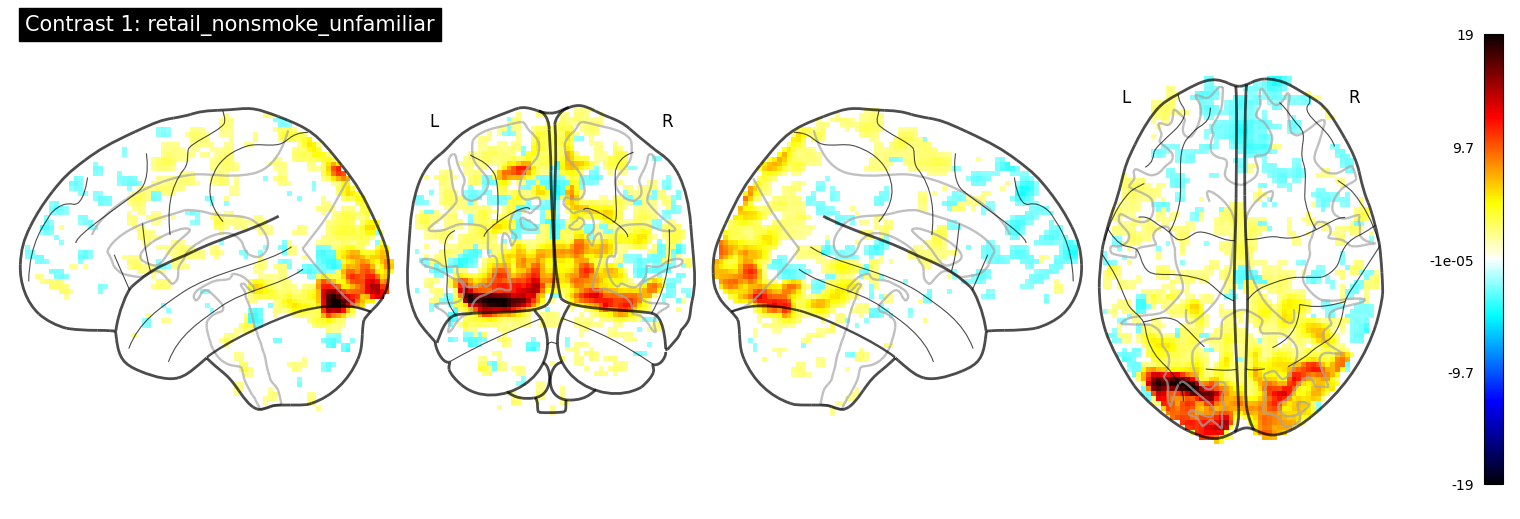

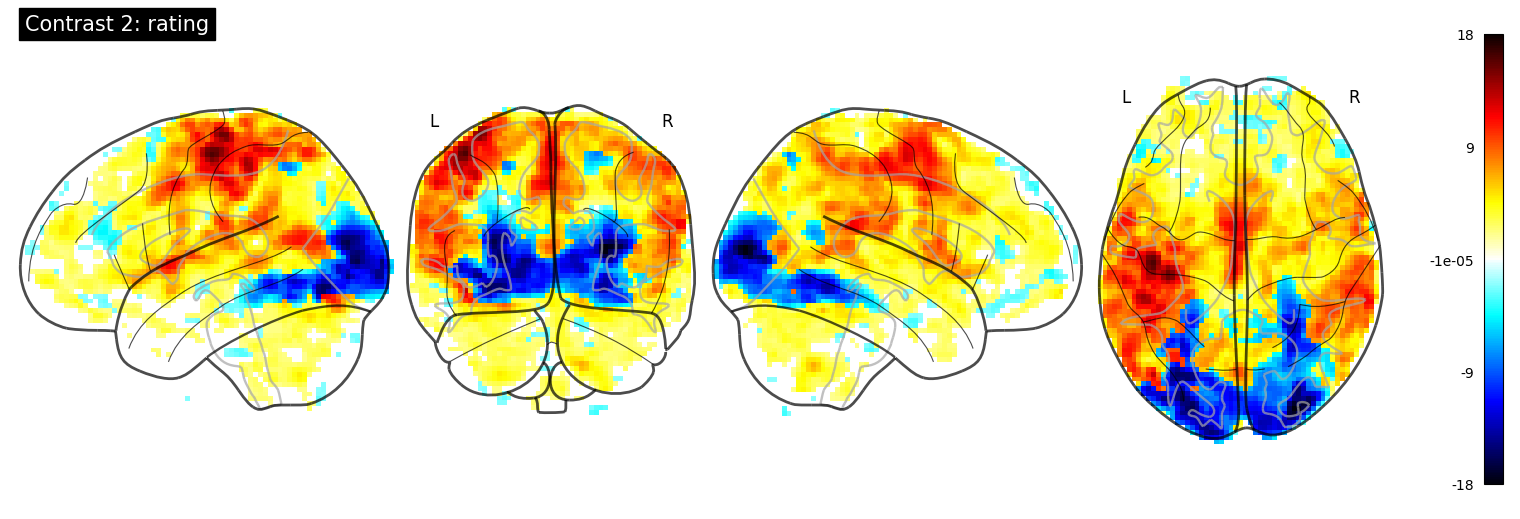

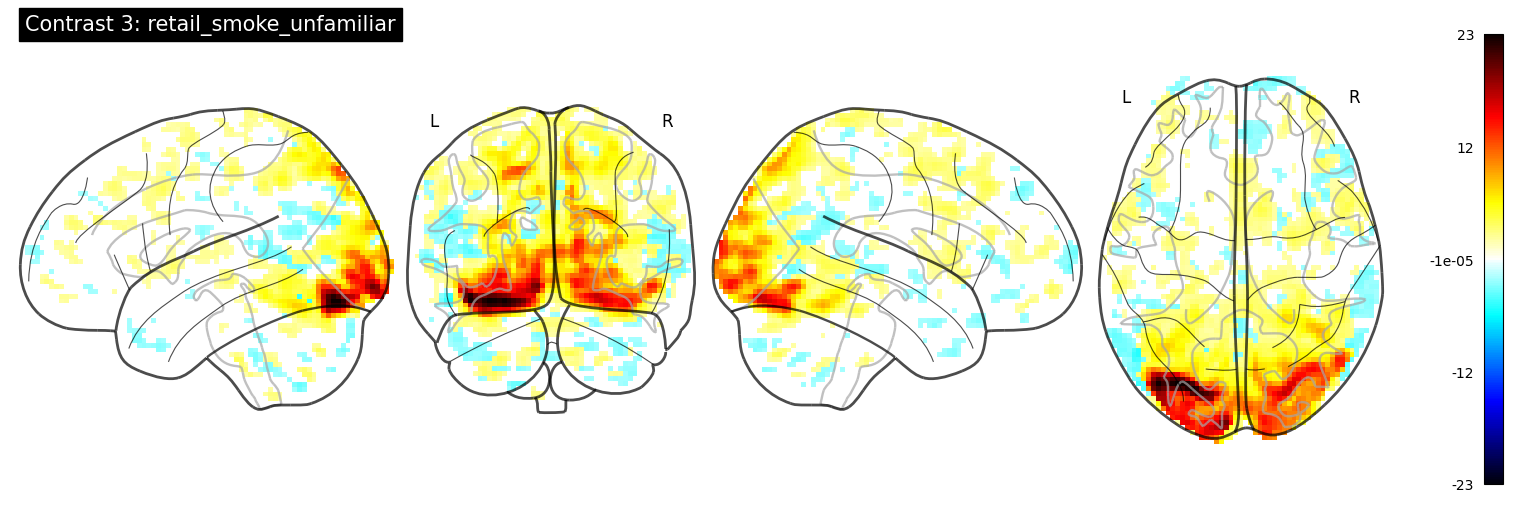

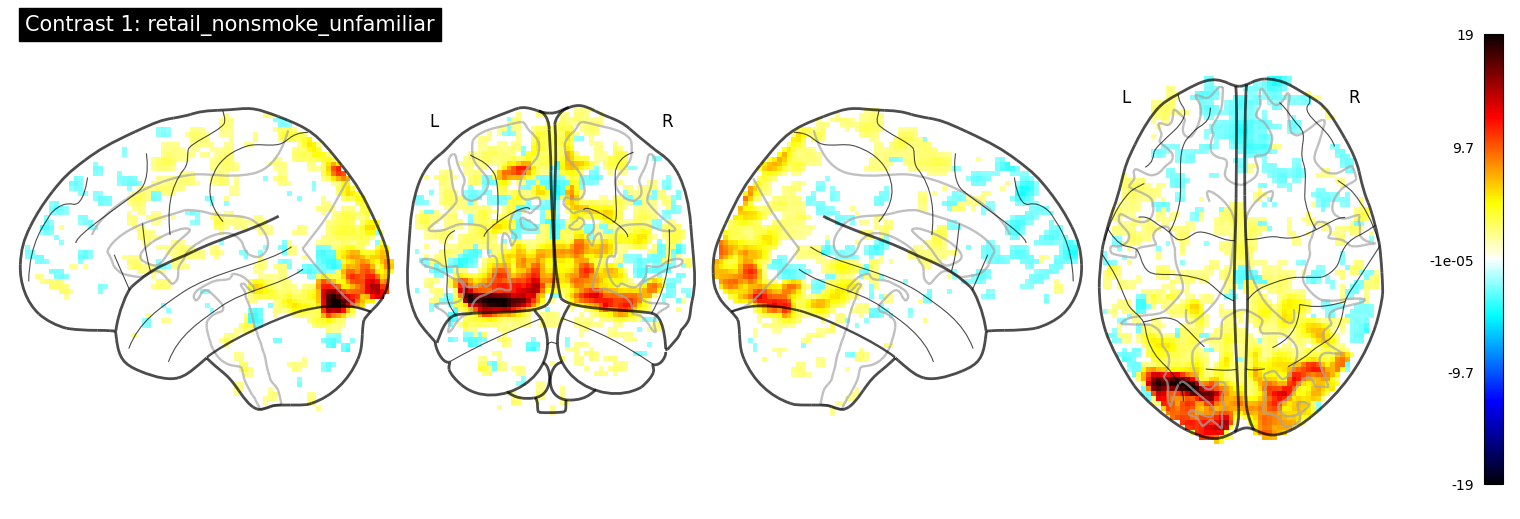

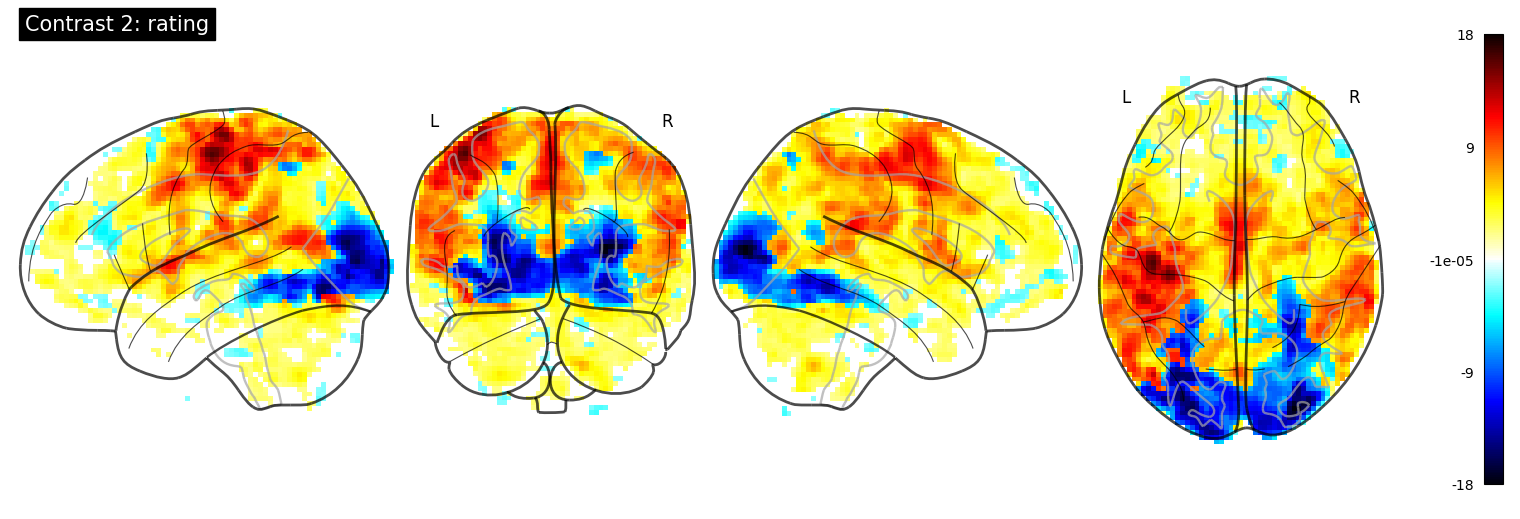

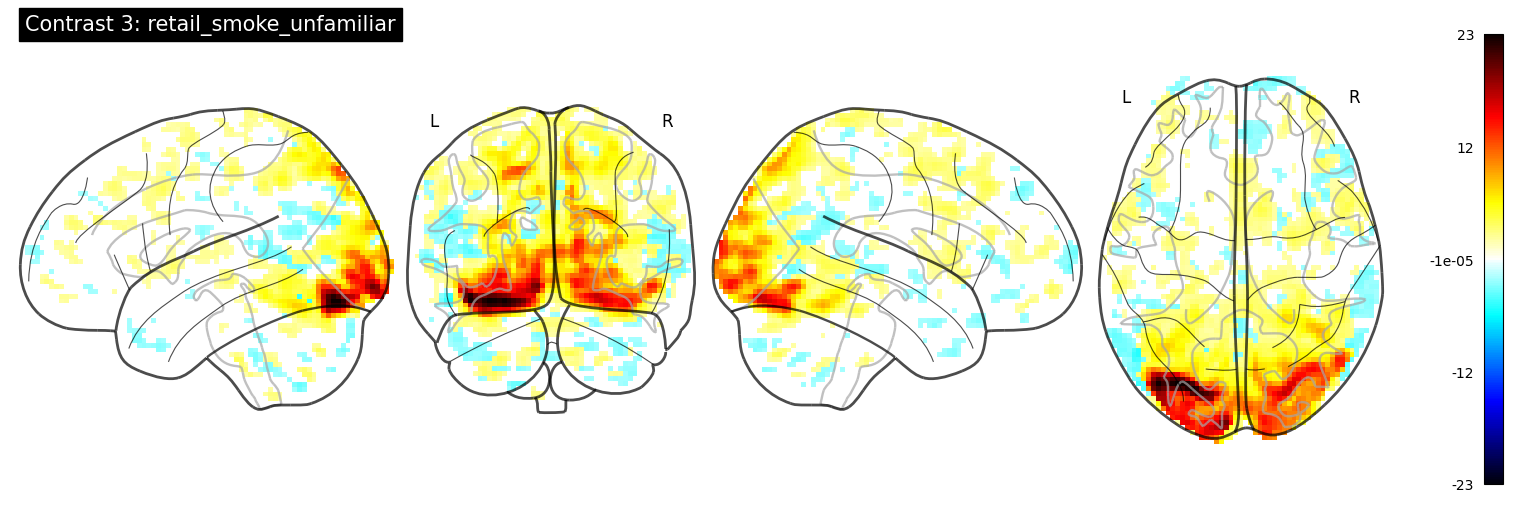

In [ ]:
# fMRI First Level Model Contrast Viewer
# Interactive notebook for viewing and exploring fMRI contrasts

import os
import glob
import numpy as np
import nibabel as nib
from scipy.io import loadmat
import matplotlib.pyplot as plt
from nilearn import plotting, datasets
from nilearn.image import threshold_img
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Configuration
BASE_PATH = "/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/nipype/task-image_model-GEO-condition/"

class ContrastViewer:
    """Interactive viewer for fMRI contrast images"""
    
    def __init__(self, model_path):
        self.model_path = model_path
        self.contrasts = []
        self.current_image = None
        self.current_data = None
        self.load_contrasts()
    
    def load_contrasts(self):
        """Load contrast information from SPM.mat"""
        spm_mat_path = os.path.join(self.model_path, 'SPM.mat')
        
        if not os.path.exists(spm_mat_path):
            print(f"SPM.mat not found in {self.model_path}")
            return
        
        try:
            spm_data = loadmat(spm_mat_path, struct_as_record=False, squeeze_me=True)
            spm = spm_data['SPM']
            
            if hasattr(spm, 'xCon') and spm.xCon.size > 0:
                xCon = spm.xCon
                if not isinstance(xCon, np.ndarray):
                    xCon = [xCon]
                
                for i, con in enumerate(xCon):
                    contrast_info = {
                        'index': i + 1,
                        'name': con.name if hasattr(con, 'name') else f'Contrast_{i+1}',
                        'type': con.STAT if hasattr(con, 'STAT') else 'T',
                        'files': self.find_contrast_files(i + 1)
                    }
                    self.contrasts.append(contrast_info)
            
            print(f"Loaded {len(self.contrasts)} contrasts from {os.path.basename(self.model_path)}")
            
        except Exception as e:
            print(f"Error reading SPM.mat: {e}")
    
    def find_contrast_files(self, contrast_idx):
        """Find all files associated with a contrast"""
        files = {}
        
        # Common contrast file patterns
        patterns = {
            'con': f"con_{contrast_idx:04d}.nii",
            'spmT': f"spmT_{contrast_idx:04d}.nii",
            'ess': f"ess_{contrast_idx:04d}.nii",
            'con_img': f"con_{contrast_idx:04d}.img",
            'spmT_img': f"spmT_{contrast_idx:04d}.img"
        }
        
        for file_type, pattern in patterns.items():
            file_path = os.path.join(self.model_path, pattern)
            if os.path.exists(file_path):
                files[file_type] = file_path
        
        return files
    
    def list_contrasts(self):
        """Display available contrasts"""
        print("Available Contrasts:")
        print("=" * 50)
        for contrast in self.contrasts:
            print(f"Index: {contrast['index']}")
            print(f"Name: {contrast['name']}")
            print(f"Type: {contrast['type']}")
            print(f"Available files: {list(contrast['files'].keys())}")
            print("-" * 30)
    
    def load_image(self, contrast_idx, image_type='con'):
        """Load a specific contrast image"""
        contrast = None
        for c in self.contrasts:
            if c['index'] == contrast_idx:
                contrast = c
                break
        
        if not contrast:
            print(f"Contrast {contrast_idx} not found")
            return None
        
        if image_type not in contrast['files']:
            available = list(contrast['files'].keys())
            print(f"Image type '{image_type}' not available. Available types: {available}")
            if available:
                image_type = available[0]
                print(f"Using '{image_type}' instead")
            else:
                return None
        
        try:
            img_path = contrast['files'][image_type]
            img = nib.load(img_path)
            self.current_image = img
            self.current_data = img.get_fdata()
            print(f"Loaded: {os.path.basename(img_path)}")
            print(f"Shape: {self.current_data.shape}")
            print(f"Data range: {self.current_data.min():.3f} to {self.current_data.max():.3f}")
            return img
        except Exception as e:
            print(f"Error loading image: {e}")
            return None
    
    def plot_glass_brain(self, contrast_idx, image_type='spmT', threshold=2.0):
        """Plot glass brain view of contrast"""
        img = self.load_image(contrast_idx, image_type)
        if img is None:
            return
        
        # Apply threshold
        thresholded_img = threshold_img(img, threshold=threshold)
        
        # Create glass brain plot
        fig = plt.figure(figsize=(15, 5))
        plotting.plot_glass_brain(thresholded_img, 
                                colorbar=True, 
                                title=f"Contrast {contrast_idx}: {self.contrasts[contrast_idx-1]['name']}",
                                plot_abs=False,
                                display_mode='lyrz',
                                figure=fig)
        plt.show()
    
    def plot_stat_map(self, contrast_idx, image_type='spmT', threshold=2.0, cut_coords=None):
        """Plot statistical map overlay on anatomical template"""
        img = self.load_image(contrast_idx, image_type)
        if img is None:
            return
        
        # Apply threshold
        thresholded_img = threshold_img(img, threshold=threshold)
        
        try:
            # Load anatomical template
            anat_img = datasets.load_mni152_template(resolution=2)
            
            # Create stat map overlay
            fig = plt.figure(figsize=(15, 5))
            plotting.plot_stat_map(thresholded_img,
                                 bg_img=anat_img,
                                 display_mode='ortho',
                                 colorbar=True,
                                 title=f"Contrast {contrast_idx}: {self.contrasts[contrast_idx-1]['name']}",
                                 cut_coords=cut_coords,
                                 figure=fig)
            plt.show()
            
        except Exception as e:
            print(f"Error creating stat map: {e}")
    
    def plot_mosaic(self, contrast_idx, image_type='spmT', threshold=2.0):
        """Plot mosaic view of statistical map"""
        img = self.load_image(contrast_idx, image_type)
        if img is None:
            return
        
        # Apply threshold
        thresholded_img = threshold_img(img, threshold=threshold)
        
        # Create mosaic plot
        fig = plt.figure(figsize=(16, 12))
        plotting.plot_stat_map(thresholded_img,
                             display_mode='mosaic',
                             colorbar=True,
                             title=f"Contrast {contrast_idx}: {self.contrasts[contrast_idx-1]['name']}",
                             figure=fig)
        plt.show()
    
    def plot_surface(self, contrast_idx, image_type='spmT', threshold=2.0, hemisphere='both'):
        """Plot surface projection of statistical map"""
        img = self.load_image(contrast_idx, image_type)
        if img is None:
            return
        
        # Apply threshold
        thresholded_img = threshold_img(img, threshold=threshold)
        
        try:
            from nilearn.surface import vol_to_surf
            
            # Load surface data
            fsaverage = datasets.fetch_surf_fsaverage()
            
            if hemisphere in ['left', 'both']:
                try:
                    # Project volume to surface
                    surf_data_left = vol_to_surf(thresholded_img, fsaverage['pial_left'])
                    
                    # Only plot if there's significant data
                    if np.any(np.abs(surf_data_left) > 0):
                        fig = plt.figure(figsize=(12, 8))
                        plotting.plot_surf_stat_map(fsaverage['pial_left'],
                                                  surf_data_left,
                                                  hemi='left',
                                                  title=f"Left Hemisphere - Contrast {contrast_idx}",
                                                  colorbar=True,
                                                  view='lateral',
                                                  figure=fig)
                        plt.show()
                    else:
                        print("No significant activations found on left hemisphere surface")
                except Exception as e:
                    print(f"Left hemisphere surface mapping failed: {e}")
            
            if hemisphere in ['right', 'both']:
                try:
                    # Project volume to surface
                    surf_data_right = vol_to_surf(thresholded_img, fsaverage['pial_right'])
                    
                    # Only plot if there's significant data
                    if np.any(np.abs(surf_data_right) > 0):
                        fig = plt.figure(figsize=(12, 8))
                        plotting.plot_surf_stat_map(fsaverage['pial_right'],
                                                  surf_data_right,
                                                  hemi='right',
                                                  title=f"Right Hemisphere - Contrast {contrast_idx}",
                                                  colorbar=True,
                                                  view='lateral',
                                                  figure=fig)
                        plt.show()
                    else:
                        print("No significant activations found on right hemisphere surface")
                except Exception as e:
                    print(f"Right hemisphere surface mapping failed: {e}")
                
        except ImportError:
            print("Surface plotting requires nilearn with surface support")
        except Exception as e:
            print(f"Surface plotting not available: {e}")
            print("Note: Surface plotting requires volume-to-surface mapping")
    
    def plot_all_views(self, contrast_idx, image_type='spmT', threshold=2.0):
        """Plot all visualization types for a contrast"""
        print(f"Generating all views for Contrast {contrast_idx}: {self.contrasts[contrast_idx-1]['name']}")
        print("=" * 60)
        
        print("\n1. Glass Brain View:")
        self.plot_glass_brain(contrast_idx, image_type, threshold)
        
        print("\n2. Statistical Map Overlay:")
        self.plot_stat_map(contrast_idx, image_type, threshold)
        
        print("\n3. Mosaic View:")
        self.plot_mosaic(contrast_idx, image_type, threshold)
        
        print("\n4. Surface Views:")
        self.plot_surface(contrast_idx, image_type, threshold, 'both')
    def interactive_viewer(self, contrast_idx, image_type='spmT'):
        """Create interactive viewer with multiple visualization options"""
        img = self.load_image(contrast_idx, image_type)
        if img is None:
            return
        
        # Create widgets
        threshold_slider = widgets.FloatSlider(
            value=2.0, min=0, max=10, step=0.1, 
            description='Threshold:', style={'description_width': 'initial'}
        )
        
        view_type = widgets.Dropdown(
            options=[
                ('Glass Brain', 'glass_brain'),
                ('Statistical Map', 'stat_map'), 
                ('Mosaic View', 'mosaic'),
                ('Surface - Left', 'surface_left'),
                ('Surface - Right', 'surface_right'),
                ('All Views', 'all')
            ],
            value='glass_brain',
            description='View Type:', 
            style={'description_width': 'initial'}
        )
        
        image_type_widget = widgets.Dropdown(
            options=list(self.contrasts[contrast_idx-1]['files'].keys()),
            value=image_type if image_type in self.contrasts[contrast_idx-1]['files'] else list(self.contrasts[contrast_idx-1]['files'].keys())[0],
            description='Image Type:', 
            style={'description_width': 'initial'}
        )
        
        def update_plot(threshold, view, img_type):
            clear_output(wait=True)
            
            # Reload image if type changed
            if img_type != image_type:
                self.load_image(contrast_idx, img_type)
            
            print(f"Contrast {contrast_idx}: {self.contrasts[contrast_idx-1]['name']}")
            print(f"Image: {img_type}, Threshold: {threshold}, View: {view}")
            print("-" * 50)
            
            if view == 'glass_brain':
                self.plot_glass_brain(contrast_idx, img_type, threshold)
            elif view == 'stat_map':
                self.plot_stat_map(contrast_idx, img_type, threshold)
            elif view == 'mosaic':
                self.plot_mosaic(contrast_idx, img_type, threshold)
            elif view == 'surface_left':
                self.plot_surface(contrast_idx, img_type, threshold, 'left')
            elif view == 'surface_right':
                self.plot_surface(contrast_idx, img_type, threshold, 'right')
            elif view == 'all':
                self.plot_all_views(contrast_idx, img_type, threshold)
        
        # Create interactive plot
        return widgets.interact(update_plot, 
                              threshold=threshold_slider, 
                              view=view_type,
                              img_type=image_type_widget)
    
    def compare_contrasts(self, contrast_indices, image_type='spmT', threshold=2.0, view_type='glass_brain'):
        """Compare multiple contrasts side by side"""
        if len(contrast_indices) > 4:
            print("Maximum 4 contrasts can be compared at once")
            contrast_indices = contrast_indices[:4]
        
        if view_type == 'glass_brain':
            fig, axes = plt.subplots(len(contrast_indices), 1, figsize=(15, 4*len(contrast_indices)))
            if len(contrast_indices) == 1:
                axes = [axes]
            
            for i, contrast_idx in enumerate(contrast_indices):
                img = self.load_image(contrast_idx, image_type)
                if img is not None:
                    thresholded_img = threshold_img(img, threshold=threshold)
                    plotting.plot_glass_brain(thresholded_img,
                                            axes=axes[i],
                                            colorbar=True,
                                            title=f"Contrast {contrast_idx}: {self.contrasts[contrast_idx-1]['name']}",
                                            display_mode='lyrz')
            plt.tight_layout()
            plt.show()
        
        elif view_type == 'stat_map':
            # Load anatomical template
            try:
                anat_img = datasets.load_mni152_template(resolution=2)
                
                for contrast_idx in contrast_indices:
                    img = self.load_image(contrast_idx, image_type)
                    if img is not None:
                        thresholded_img = threshold_img(img, threshold=threshold)
                        fig = plt.figure(figsize=(15, 4))
                        plotting.plot_stat_map(thresholded_img,
                                             bg_img=anat_img,
                                             display_mode='ortho',
                                             colorbar=True,
                                             title=f"Contrast {contrast_idx}: {self.contrasts[contrast_idx-1]['name']}",
                                             figure=fig)
                        plt.show()
            except Exception as e:
                print(f"Error in comparison: {e}")
    
    def interactive_comparison(self):
        """Interactive widget for comparing contrasts"""
        contrast_options = [(f"{c['index']}: {c['name']}", c['index']) for c in self.contrasts]
        
        contrast_selector = widgets.SelectMultiple(
            options=contrast_options,
            description='Contrasts:',
            style={'description_width': 'initial'},
            layout={'height': '150px'}
        )
        
        threshold_slider = widgets.FloatSlider(
            value=2.0, min=0, max=10, step=0.1,
            description='Threshold:'
        )
        
        view_dropdown = widgets.Dropdown(
            options=[('Glass Brain', 'glass_brain'), ('Statistical Map', 'stat_map')],
            value='glass_brain',
            description='View Type:'
        )
        
        image_type_dropdown = widgets.Dropdown(
            options=['spmT', 'con', 'ess'],
            value='spmT',
            description='Image Type:'
        )
        
        def update_comparison(contrasts, threshold, view, img_type):
            if contrasts:
                clear_output(wait=True)
                self.compare_contrasts(list(contrasts), img_type, threshold, view)
        
        return widgets.interact(update_comparison,
                              contrasts=contrast_selector,
                              threshold=threshold_slider,
                              view=view_dropdown,
                              img_type=image_type_dropdown)

def get_subjects():
    """Get list of available subjects"""
    subjects = []
    subject_dirs = glob.glob(os.path.join(BASE_PATH, "sub-*"))
    for subject_dir in subject_dirs:
        if os.path.isdir(subject_dir):
            subjects.append(os.path.basename(subject_dir))
    return sorted(subjects)

def create_subject_viewer(subject_id):
    """Create viewer for a specific subject"""
    subject_path = os.path.join(BASE_PATH, subject_id)
    if not os.path.exists(subject_path):
        print(f"Subject path not found: {subject_path}")
        return None
    
    return ContrastViewer(subject_path)

# Example usage functions
def quick_start():
    """Quick start guide with neuroimaging best practices"""
    print("fMRI Contrast Viewer - Quick Start")
    print("=" * 40)
    print("Best practices for viewing fMRI contrasts:")
    print()
    print("🧠 GLASS BRAIN VIEW:")
    print("   - Best for: Overview of all activations")
    print("   - Shows: Transparent brain with statistical overlay")
    print("   - Usage: viewer.plot_glass_brain(contrast_idx=1)")
    print()
    print("📍 STATISTICAL MAP OVERLAY:")
    print("   - Best for: Precise anatomical localization")
    print("   - Shows: Activations on anatomical template")
    print("   - Usage: viewer.plot_stat_map(contrast_idx=1)")
    print()
    print("🗂️ MOSAIC VIEW:")
    print("   - Best for: Comprehensive coverage, publications")
    print("   - Shows: Multiple axial slices")
    print("   - Usage: viewer.plot_mosaic(contrast_idx=1)")
    print()
    print("🌐 SURFACE VIEW:")
    print("   - Best for: Cortical activations")
    print("   - Shows: Inflated cortical surface")
    print("   - Usage: viewer.plot_surface(contrast_idx=1)")
    print()
    print("GETTING STARTED:")
    print("1. subjects = get_subjects()")
    print("2. viewer = create_subject_viewer('sub-GEO04')")
    print("3. viewer.list_contrasts()")
    print("4. viewer.plot_all_views(contrast_idx=1)  # See everything!")
    print("5. viewer.interactive_viewer(contrast_idx=1)  # Interactive!")
    print()
    print("COMPARISON:")
    print("viewer.interactive_comparison()  # Compare multiple contrasts")

def create_batch_viewer():
    """Create a widget for viewing multiple subjects"""
    subjects = get_subjects()
    
    subject_dropdown = widgets.Dropdown(
        options=subjects,
        description='Subject:',
        style={'description_width': 'initial'}
    )
    
    def create_viewer_for_subject(subject):
        clear_output(wait=True)
        print(f"Loading viewer for {subject}...")
        viewer = create_subject_viewer(subject)
        if viewer and viewer.contrasts:
            print(f"✓ Loaded {len(viewer.contrasts)} contrasts")
            display(viewer.list_contrasts())
            
            # Create quick access buttons
            print("\nQuick Actions:")
            
            def show_all_contrasts():
                for i, contrast in enumerate(viewer.contrasts[:3]):  # Show first 3
                    print(f"\nShowing contrast {contrast['index']}: {contrast['name']}")
                    viewer.plot_glass_brain(contrast['index'])
            
            def show_interactive():
                if viewer.contrasts:
                    return viewer.interactive_viewer(viewer.contrasts[0]['index'])
            
            def show_comparison():
                return viewer.interactive_comparison()
            
            button_layout = widgets.Layout(width='200px', margin='5px')
            
            overview_btn = widgets.Button(description="Show Overview", layout=button_layout)
            interactive_btn = widgets.Button(description="Interactive Viewer", layout=button_layout)
            compare_btn = widgets.Button(description="Compare Contrasts", layout=button_layout)
            
            overview_btn.on_click(lambda x: show_all_contrasts())
            interactive_btn.on_click(lambda x: show_interactive())
            compare_btn.on_click(lambda x: show_comparison())
            
            display(widgets.HBox([overview_btn, interactive_btn, compare_btn]))
            
            return viewer
        else:
            print("❌ No contrasts found or error loading subject")
            return None
    
    return widgets.interact(create_viewer_for_subject, subject=subject_dropdown)

# Advanced analysis functions
def export_activation_coordinates(viewer, contrast_idx, threshold=3.0, min_cluster_size=10):
    """Export peak activation coordinates (requires scipy.ndimage)"""
    try:
        from scipy import ndimage
        from nilearn.reporting import get_clusters_table
        
        img = viewer.load_image(contrast_idx, 'spmT')
        if img is None:
            return None
        
        # Get clusters table
        clusters_table = get_clusters_table(
            img, 
            stat_threshold=threshold,
            cluster_threshold=min_cluster_size
        )
        
        print(f"Activation clusters for contrast {contrast_idx} (t > {threshold}):")
        print("=" * 60)
        print(clusters_table.to_string(index=False))
        
        return clusters_table
        
    except ImportError:
        print("scipy.ndimage required for cluster analysis")
        return None

def generate_contrast_summary(viewer):
    """Generate a summary report of all contrasts"""
    print("CONTRAST SUMMARY REPORT")
    print("=" * 50)
    print(f"Subject: {os.path.basename(viewer.model_path)}")
    print(f"Total contrasts: {len(viewer.contrasts)}")
    print(f"Model path: {viewer.model_path}")
    print()
    
    for contrast in viewer.contrasts:
        print(f"Contrast {contrast['index']}: {contrast['name']}")
        print(f"  Type: {contrast['type']}")
        print(f"  Available files: {list(contrast['files'].keys())}")
        
        # Try to load and get basic stats
        try:
            img = viewer.load_image(contrast['index'], 'spmT' if 'spmT' in contrast['files'] else 'con')
            if img is not None:
                data = viewer.current_data
                print(f"  Max value: {data.max():.3f}")
                print(f"  Min value: {data.min():.3f}")
                print(f"  Voxels > 2.0: {np.sum(np.abs(data) > 2.0)}")
        except:
            print("  Could not load image data")
        print()

# Run quick start
quick_start()

# Create batch viewer widget
print("\n" + "="*50)
print("BATCH VIEWER - Select subject to explore:")
batch_viewer = create_batch_viewer()

### Get a list of Subjects

In [ ]:
subjects = get_subjects()
print(subjects)

### Create a Viewer for a subject

In [ ]:
viewer = create_subject_viewer(subjects[0])

### List available contrasts

In [ ]:
viewer.list_contrasts()

In [ ]:
viewer.plot_slices(contrast_idx=1)


In [ ]:
viewer.interactive_viewer(contrast_idx=1)
